# Transaction Fraud Detection Data Processing & Model 

### Dataset overview:

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

df = pd.read_csv("30daysData.csv")
df.head()


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [2]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00



There are in total 6362620 transaction records in this dataset, each row represent a single transaction information.
number of colunms: 11
Columns Summary:
- `step`: Time step of the transaction
- `type`: 5 Transaction types: payment, transfer, cash_out,  cash_in,  debit 
- `amount`: Transaction amount
- `oldbalanceOrg`, `newbalanceOrig`: Account balance of the origin account before and after the transaction
- `oldbalanceDest`, `newbalanceDest`: Account balance of the destination account before and after the transaction
- `isFraud`: Target label indicating whether the transaction is fraudulent (1) or not (0)
- `isFlaggedFraud`: System flag for fraud transactions

####  Data Quality Validation

In [3]:
# Check missing values per column
df.isnull().sum()
# Check for negative transaction
(df[["amount", 
     "oldbalanceOrg", "newbalanceOrig", 
     "oldbalanceDest", "newbalanceDest"]] < 0).sum()
df[["amount", 
    "oldbalanceOrg", "newbalanceOrig", 
    "oldbalanceDest", "newbalanceDest"]].max()


amount            9.244552e+07
oldbalanceOrg     5.958504e+07
newbalanceOrig    4.958504e+07
oldbalanceDest    3.560159e+08
newbalanceDest    3.561793e+08
dtype: float64

- No missing values are detected in any columns
- All monetary variables are non-negative
- The maximum transaction amount exceeds 92 million, indicating a highly skewed
  and long-tailed distribution.

#### Feature Engineering

In [4]:
# Create engineered features: balance changes caused by the transaction
df["balanceDiffOrg"] = df["oldbalanceOrg"] - df["newbalanceOrig"]
df["balanceDiffDest"] = df["newbalanceDest"] - df["oldbalanceDest"]

# Quick sanity check: confirm the new columns exist and preview a few values
df[["oldbalanceOrg", "newbalanceOrig", "balanceDiffOrg",
    "oldbalanceDest", "newbalanceDest", "balanceDiffDest"]].head()


,oldbalanceOrg,newbalanceOrig,balanceDiffOrg,oldbalanceDest,newbalanceDest,balanceDiffDest
0,170136.0,160296.36,9839.64,0.0,0.0,0.0
1,21249.0,19384.72,1864.28,0.0,0.0,0.0
2,181.0,0.00,181.00,0.0,0.0,0.0
3,181.0,0.00,181.00,21182.0,0.0,-21182.0
4,41554.0,29885.86,11668.14,0.0,0.0,0.0


#### Exploratory Data Analysis
##### Class Distribution of Fraud vs Non-Fraud

Matplotlib is building the font cache; this may take a moment.


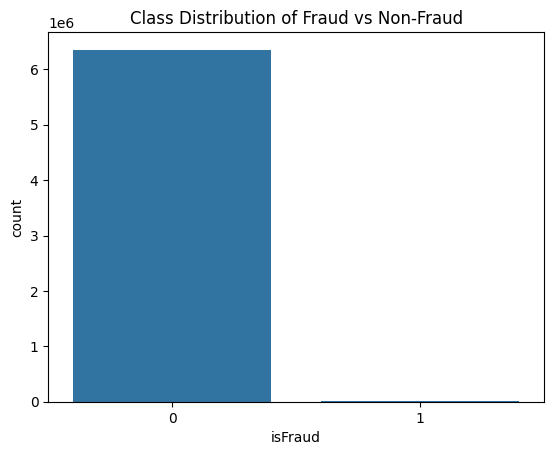

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="isFraud", data=df)
plt.title("Class Distribution of Fraud vs Non-Fraud")
plt.show()

- The dataset is highly imbalanced, only every small amount of Fraud transaction in this dataset.

##### Fraud Distribution Across Transaction Types

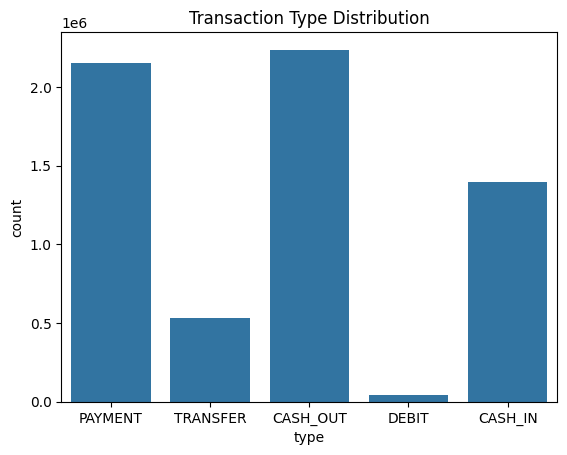

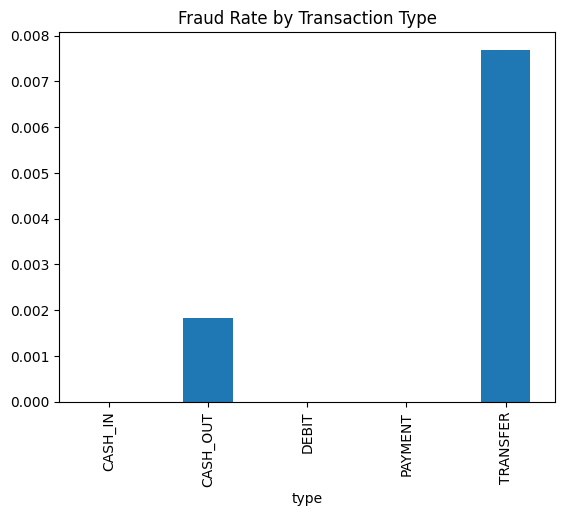

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

# Transaction type distribution
sns.countplot(x="type", data=df)
plt.title("Transaction Type Distribution")
plt.show()

# Fraud rate by transaction type
fraud_rate_by_type = df.groupby("type")["isFraud"].mean()
fraud_rate_by_type.plot(kind="bar")
plt.title("Fraud Rate by Transaction Type")
plt.show()


- Most transactions are CASH_OUT and PAYMENT, while DEBIT transactions are very rare.
- Fraud occurs almost entirely in TRANSFER and CASH_OUT transactions, with little to no fraud in other types.

##### Transaction Amount Distribution

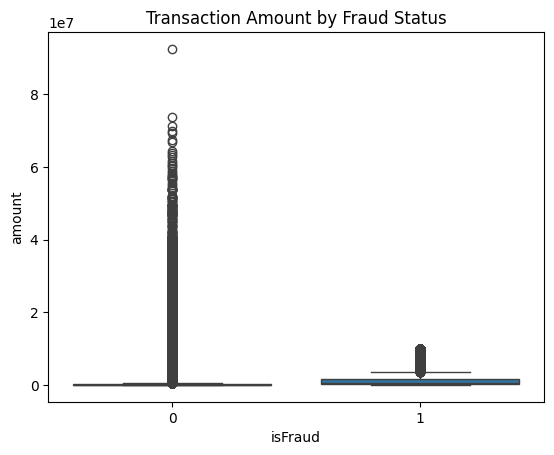

In [7]:
sns.boxplot(x="isFraud", y="amount", data=df)
plt.title("Transaction Amount by Fraud Status")
plt.show()


There is significant overlap between the two groups, so transaction amount alone cannot clearly separate fraud from non-fraud.

##### Balance Change of Origin Account by Fraud Status

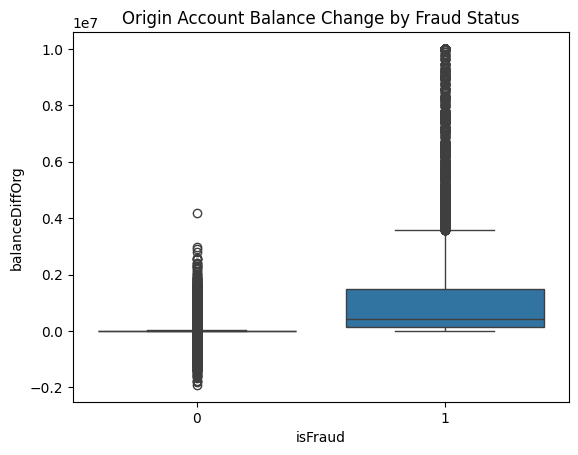

In [8]:
sns.boxplot(x="isFraud", y="balanceDiffOrg", data=df)
plt.title("Origin Account Balance Change by Fraud Status")
plt.show()


- For non-fraud transactions, the balance change of the origin account is usually close to zero.

- Fraudulent transactions show much larger balance decreases in the origin account.

- This indicates that origin account balance change maybe a strong signal for distinguishing fraud from non-fraud.

##### Destination Account Balance Change by Fraud Status

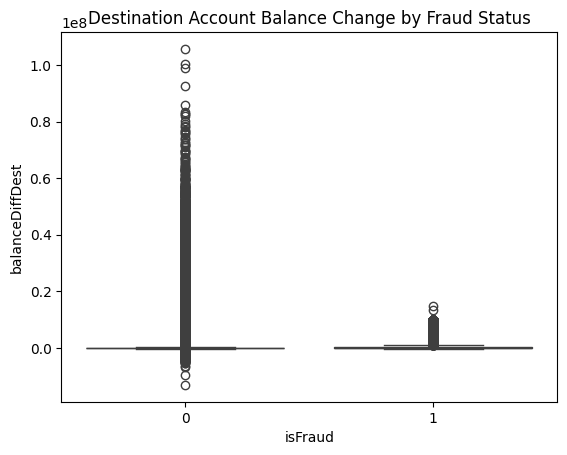

In [9]:
sns.boxplot(x="isFraud", y="balanceDiffDest", data=df)
plt.title("Destination Account Balance Change by Fraud Status")
plt.show()


- Fraud transactions have smaller and more concentrated destination balance increases.

- Destination balance change is less informative than origin balance change.

#### numeric correlation heatmap

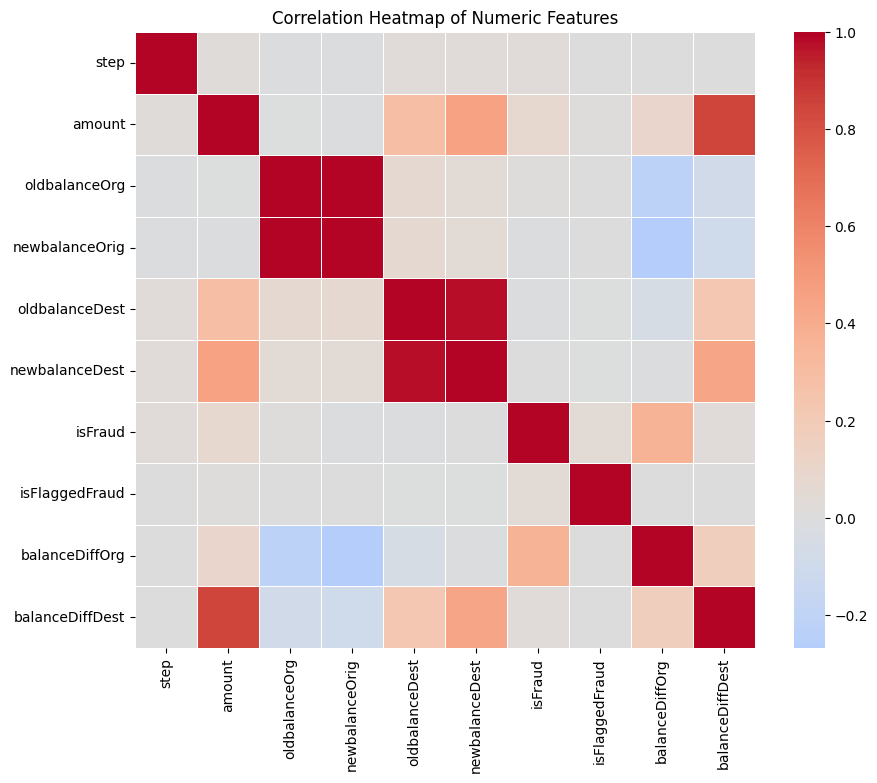

In [10]:
# Select numeric columns only
numeric_df = df.select_dtypes(include=["int64", "float64"])

plt.figure(figsize=(10, 8))
sns.heatmap(
    numeric_df.corr(),
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)
plt.title("Correlation Heatmap of Numeric Features")
plt.show()


- isFlaggedFraud adds almost no value and can be ignored.
- balanceDiffOrg is more useful for spotting fraud than using balances before and after separately.

- Fraud is not determined by transaction amount alone.
- Fraud mainly happens in TRANSFER and CASH_OUT transactions.
- Balance change features, especially origin account balance change, are more
  useful than looking at balances before and after separately.

Based on these findings, we proceed to the modeling stage using the most
informative features identified during EDA.


### Modeling and Evaluation
#### Feature Selection for Modeling

Delete unuseful columns: "nameOrig", "nameDest" are pure ID string, and 'isFlaggedFraud' is almost always 0, providing little help

In [11]:
df = df.drop(["nameOrig", "nameDest", "isFlaggedFraud"], axis=1)
#  

The transaction type should be encoded into numeric form, so it can be used by machine learning models while preserving its categorical information.
- CASH_IN → 0  
- CASH_OUT → 1  
- DEBIT → 2  
- PAYMENT → 3  
- TRANSFER → 4  

In [12]:
df["type_code"] = df["type"].astype('category').cat.codes
df = df.drop("type", axis=1)
# Show first 5 rows after processing
df.head()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,balanceDiffOrg,balanceDiffDest,type_code
0,1,9839.64,170136.0,160296.36,0.0,0.0,0,9839.64,0.0,3
1,1,1864.28,21249.0,19384.72,0.0,0.0,0,1864.28,0.0,3
2,1,181.00,181.0,0.00,0.0,0.0,1,181.00,0.0,4
3,1,181.00,181.0,0.00,21182.0,0.0,1,181.00,-21182.0,1
4,1,11668.14,41554.0,29885.86,0.0,0.0,0,11668.14,0.0,3


In [13]:
df.shape

(6362620, 10)

##### Data processing results
After preprocessing and feature engineering, the dataset contains 10 columns.
The target variable is `isFraud`, and the remaining features are used as inputs for model training.

#### Prototype Dataset Construction
The original dataset is very large and extremely imbalanced, with more than 6 million transactions. To enable faster experimentation, a smaller dataset is constructed for prototyping purposes.

Approximately 70,000 transactions (about 1% of the original dataset) are used.
Since fraud cases are rare, all fraud transactions are kept, while non-fraud transactions are randomly sampled. The selected samples are then combined and shuffled to form the prototype dataset.

In [14]:
df_fraud = df[df["isFraud"] == 1]
df_nonfraud = df[df["isFraud"] == 0]
print("fraud cases：", len(df_fraud))
print("non-fraud cases", len(df_nonfraud))

target_size = 70000
n_fraud = len(df_fraud)
n_nonfraud_sample = target_size - n_fraud

# sampling from non-fraud cases separately
df_nonfraud_sample = df_nonfraud.sample(
    n=n_nonfraud_sample,
    random_state=42
)
# combine and mix them all
df_proto = pd.concat([df_fraud, df_nonfraud_sample], axis=0)
df_proto = df_proto.sample(frac=1.0, random_state=42).reset_index(drop=True)

print("\nPrototype shape：", df_proto.shape)
print("# non-fraud cases vs isFraud cases in Prototype dataset ：")
print(df_proto["isFraud"].value_counts())


fraud cases： 8213
non-fraud cases 6354407

Prototype shape： (70000, 10)
# non-fraud cases vs isFraud cases in Prototype dataset ：
isFraud
0    61787
1     8213
Name: count, dtype: int64


##### Train–Test Split
Before training the model, the dataset is split into training and testing sets.
Features (`X`),which are 10 columns, and labels (`y`) are separated for supervised learning.

In [15]:
X = df_proto.drop(columns=["isFraud"]) 
y = df_proto["isFraud"] 

print("\nfeatures X shape：", X.shape)
print("lable y shape：", y.shape)




features X shape： (70000, 9)
lable y shape： (70000,)


The dataset is split into training and testing sets (80% / 20%).
The training set is used to train the model, while the test set is used to evaluate how well the model performs on unseen data.
Stratified sampling is applied to keep the fraud and non-fraud ratio consistent in both sets.

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,        
    random_state=42
)

print("\n train size：", X_train.shape[0])
print("test：", X_test.shape[0])

print("\ntrain isFraud distribution：")
print(y_train.value_counts())
print("\ntest isFraud distribution：")
print(y_test.value_counts())


 train size： 56000
test： 14000

train isFraud distribution：
isFraud
0    49430
1     6570
Name: count, dtype: int64

test isFraud distribution：
isFraud
0    12357
1     1643
Name: count, dtype: int64


we choose 3 models(Decision Tree, Random Forest,and KNN) and train them, compare their performance of detecting fraudulent transactions

In [17]:
#  Decision Tree (balanced because fraud cases are way less than non-fraud)
dt_clf = DecisionTreeClassifier(
    random_state=42,
    class_weight="balanced"   
)

#  Random Forest (balanced because fraud cases are way less than non-fraud)
rf_clf = RandomForestClassifier(
    n_estimators=100,         
    random_state=42,
    n_jobs=-1,                
    class_weight="balanced"   
)

# KNN 
knn_pipeline = Pipeline(steps=[
    ("scaler", StandardScaler()), 
    ("knn", KNeighborsClassifier(n_neighbors=5)) 
])

print("\ntrain 3 models")
dt_clf.fit(X_train, y_train)
rf_clf.fit(X_train, y_train)
knn_pipeline.fit(X_train, y_train)



train 3 models


,steps,"[('scaler', ...), ('knn', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30


#### Model Evaluation and Selection

In [18]:
def evaluate_model(name, model, X_test, y_test):
    print("\n==================================")
    print("Model Evaluation：", name)
    print("==================================")
    y_pred = model.predict(X_test)

    print("confusion_matrix")
    print(confusion_matrix(y_test, y_pred))

    print("\nclassification_report / Recall / F1）：")
    print(classification_report(y_test, y_pred, digits=4))

In [19]:
#  Decision Tree Evaluation
evaluate_model("Decision Tree", dt_clf, X_test, y_test)


Model Evaluation： Decision Tree
confusion_matrix
[[12309    48]
 [   40  1603]]

classification_report / Recall / F1）：
              precision    recall  f1-score   support

           0     0.9968    0.9961    0.9964     12357
           1     0.9709    0.9757    0.9733      1643

    accuracy                         0.9937     14000
   macro avg     0.9838    0.9859    0.9849     14000
weighted avg     0.9937    0.9937    0.9937     14000



In [20]:
#  Random Forest Evaluation
evaluate_model("Random Forest  K = 5", rf_clf, X_test, y_test)


Model Evaluation： Random Forest  K = 5
confusion_matrix
[[12324    33]
 [   14  1629]]

classification_report / Recall / F1）：
              precision    recall  f1-score   support

           0     0.9989    0.9973    0.9981     12357
           1     0.9801    0.9915    0.9858      1643

    accuracy                         0.9966     14000
   macro avg     0.9895    0.9944    0.9919     14000
weighted avg     0.9967    0.9966    0.9967     14000



In [21]:
#  KNN Evaluation
evaluate_model("KNN (with StandardScaler)", knn_pipeline, X_test, y_test)


Model Evaluation： KNN (with StandardScaler)
confusion_matrix
[[12270    87]
 [  180  1463]]

classification_report / Recall / F1）：
              precision    recall  f1-score   support

           0     0.9855    0.9930    0.9892     12357
           1     0.9439    0.8904    0.9164      1643

    accuracy                         0.9809     14000
   macro avg     0.9647    0.9417    0.9528     14000
weighted avg     0.9807    0.9809    0.9807     14000



- All models show high accuracy (>98%), but accuracy is not the main focus due to class imbalance.  
- Random Forest performs the best on fraud detection, with a fraud recall of **99.15%** and an F1-score of **0.9858**, meaning it misses very few fraud cases.
- Decision Tree also performs well, with a fraud recall of **97.57%**, but is slightly worse than Random Forest.
- KNN performs the worst on fraud detection, with a fraud recall of only **89.04%**, missing a noticeable number of fraud cases.
- Based on these results, Random Forest is selected as the final model for this project.

#### Final Model Training and Saving

In [22]:
import joblib
final_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

# using 100% prototype to train
final_model.fit(X, y)

model_path = "model_proto_rf.pkl"
joblib.dump(final_model, model_path)

print("\n prototype model saved at：", model_path)

# saved features
feature_names = list(X.columns)
features_path = "model_proto_rf_features.txt"
with open(features_path, "w") as f:
    for col in feature_names:
        f.write(col + "\n")

print(" model_proto_rf_features saved at: ", features_path)




 prototype model saved at： model_proto_rf.pkl
 model_proto_rf_features saved at:  model_proto_rf_features.txt
